#### `Import Libraries`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#### `Questions`
> Merge all 3 DataFrames — what is the final combined dataset shape?

> Calculate actual delivery days for each order → `(Delivered_Date - Order_Date).dt.days`

> Which delivery partner has the highest average delivery days and highest return rate?

> Is there a correlation between delivery days and return likelihood?

> Which city-warehouse combination has the highest average delivery time?

In [2]:
# Dataset 1 — Orders
orders_data = {
    'Order_ID':    ['O001','O002','O003','O004','O005','O006','O007','O008',
                    'O009','O010','O011','O012','O013','O014','O015',
                    'O016','O017','O018','O019','O020'],

    'Customer_City': ['Mumbai','Delhi','Bangalore','Mumbai','Delhi',
                      'Bangalore','Mumbai','Delhi','Bangalore','Mumbai',
                      'Delhi','Bangalore','Mumbai','Delhi','Bangalore',
                      'Mumbai','Delhi','Bangalore','Mumbai','Delhi'],

    'Warehouse':   ['WH1','WH2','WH1','WH2','WH1',
                    'WH2','WH1','WH2','WH1','WH2',
                    'WH1','WH2','WH1','WH2','WH1',
                    'WH2','WH1','WH2','WH1','WH2'],

    'Partner_ID':  ['DP1','DP2','DP3','DP1','DP2',
                    'DP3','DP1','DP2','DP3','DP1',
                    'DP2','DP3','DP1','DP2','DP3',
                    'DP1','DP2','DP3','DP1','DP2'],

    'Order_Date':  ['2024-01-01','2024-01-03','2024-01-05','2024-01-07',
                    '2024-01-09','2024-01-11','2024-01-13','2024-01-15',
                    '2024-01-17','2024-01-19','2024-01-21','2024-01-23',
                    '2024-01-25','2024-01-27','2024-01-29','2024-02-01',
                    '2024-02-03','2024-02-05','2024-02-07','2024-02-09'],

    'Delivered_Date': ['2024-01-04','2024-01-07','2024-01-09','2024-01-11',
                       '2024-01-13','2024-01-17','2024-01-16','2024-01-19',
                       '2024-01-22','2024-01-23','2024-01-25','2024-01-28',
                       '2024-01-29','2024-02-01','2024-02-04','2024-02-05',
                       '2024-02-07','2024-02-10','2024-02-11','2024-02-14'],

    'Order_Value': [1200, 3400, 2100, 4500, 1800,
                   3200, 2700, 4100, 1500, 3800,
                   2200, 4800, 1900, 3600, 2500,
                   4200, 1700, 3900, 2800, 4600]
}

In [3]:
# Dataset 2 — Delivery Partners
partners_data = {
    'Partner_ID':   ['DP1','DP2','DP3'],
    'Partner_Name': ['FastTrack','QuickShip','SwiftMove'],
    'Region':       ['West','North','South']
}

In [4]:
# Dataset 3 — Return Records
returns_data = {
    'Order_ID':      ['O003','O006','O009','O011','O012',
                      'O014','O017','O018','O020'],
    'Return_Reason': ['Damaged','Late Delivery','Wrong Item','Late Delivery',
                      'Damaged','Late Delivery','Wrong Item','Late Delivery',
                      'Damaged'],
    'Returned':      [1, 1, 1, 1, 1, 1, 1, 1, 1]
}

#### `Step 1 :- Load and Explore Data`

In [5]:
# Convert to DataFrame
data_frame_orders = pd.DataFrame(orders_data)

data_frame_orders

,Order_ID,Customer_City,Warehouse,Partner_ID,Order_Date,Delivered_Date,Order_Value
0,O001,Mumbai,WH1,DP1,2024-01-01,2024-01-04,1200
1,O002,Delhi,WH2,DP2,2024-01-03,2024-01-07,3400
2,O003,Bangalore,WH1,DP3,2024-01-05,2024-01-09,2100
3,O004,Mumbai,WH2,DP1,2024-01-07,2024-01-11,4500
4,O005,Delhi,WH1,DP2,2024-01-09,2024-01-13,1800
5,O006,Bangalore,WH2,DP3,2024-01-11,2024-01-17,3200
6,O007,Mumbai,WH1,DP1,2024-01-13,2024-01-16,2700
7,O008,Delhi,WH2,DP2,2024-01-15,2024-01-19,4100
8,O009,Bangalore,WH1,DP3,2024-01-17,2024-01-22,1500
9,O010,Mumbai,WH2,DP1,2024-01-19,2024-01-23,3800


In [6]:
# Convert to DataFrame
data_frame_partners = pd.DataFrame(partners_data)

data_frame_partners

,Partner_ID,Partner_Name,Region
0,DP1,FastTrack,West
1,DP2,QuickShip,North
2,DP3,SwiftMove,South


In [7]:
# Convert to DataFrame
data_frame_returns = pd.DataFrame(returns_data)

data_frame_returns

,Order_ID,Return_Reason,Returned
0,O003,Damaged,1
1,O006,Late Delivery,1
2,O009,Wrong Item,1
3,O011,Late Delivery,1
4,O012,Damaged,1
5,O014,Late Delivery,1
6,O017,Wrong Item,1
7,O018,Late Delivery,1
8,O020,Damaged,1


#### `Step 2 :- Pre-Merge Validation`

In [8]:
# Check shapes and columns before merge
print(f'Orders Shape:\n{data_frame_orders.shape}')

print(f'\nPartners Shape:\n{data_frame_partners.shape}')

print(f'\nReturns Shape:\n{data_frame_returns.shape}')

print(f'\nOrders Columns:\n{data_frame_orders.columns.tolist()}')

print(f'\nPartners Columns:\n{data_frame_partners.columns.tolist()}')

print(f'\nReturns Columns:\n{data_frame_returns.columns.tolist()}')

Orders Shape:
(20, 7)

Partners Shape:
(3, 3)

Returns Shape:
(9, 3)

Orders Columns:
['Order_ID', 'Customer_City', 'Warehouse', 'Partner_ID', 'Order_Date', 'Delivered_Date', 'Order_Value']

Partners Columns:
['Partner_ID', 'Partner_Name', 'Region']

Returns Columns:
['Order_ID', 'Return_Reason', 'Returned']


#### `Step 3 :- Three-Table Merge`

In [9]:
# Merge orders with partners
data_frame_merged = pd.merge(data_frame_orders, data_frame_partners, on = 'Partner_ID', how = 'left')

# Merge with returns
data_frame_merged = pd.merge(data_frame_merged, data_frame_returns, on = 'Order_ID', how = 'left')

# Fill NaN in Returned column with 0
data_frame_merged['Returned'] = data_frame_merged['Returned'].fillna(0).astype(int)

print(f'\nReturned Value Counts:\n{data_frame_merged['Returned'].value_counts()}')

data_frame_merged


Returned Value Counts:
Returned
0    11
1     9
Name: count, dtype: int64


,Order_ID,Customer_City,Warehouse,Partner_ID,Order_Date,Delivered_Date,Order_Value,Partner_Name,Region,Return_Reason,Returned
0,O001,Mumbai,WH1,DP1,2024-01-01,2024-01-04,1200,FastTrack,West,NaN,0
1,O002,Delhi,WH2,DP2,2024-01-03,2024-01-07,3400,QuickShip,North,NaN,0
2,O003,Bangalore,WH1,DP3,2024-01-05,2024-01-09,2100,SwiftMove,South,Damaged,1
3,O004,Mumbai,WH2,DP1,2024-01-07,2024-01-11,4500,FastTrack,West,NaN,0
4,O005,Delhi,WH1,DP2,2024-01-09,2024-01-13,1800,QuickShip,North,NaN,0
5,O006,Bangalore,WH2,DP3,2024-01-11,2024-01-17,3200,SwiftMove,South,Late Delivery,1
6,O007,Mumbai,WH1,DP1,2024-01-13,2024-01-16,2700,FastTrack,West,NaN,0
7,O008,Delhi,WH2,DP2,2024-01-15,2024-01-19,4100,QuickShip,North,NaN,0
8,O009,Bangalore,WH1,DP3,2024-01-17,2024-01-22,1500,SwiftMove,South,Wrong Item,1
9,O010,Mumbai,WH2,DP1,2024-01-19,2024-01-23,3800,FastTrack,West,NaN,0


#### `Step 4 :- Delivery Days Column`

In [10]:
# Calculate actual delivery days
data_frame_merged['Delivery_Days'] = (pd.to_datetime(data_frame_merged['Delivered_Date']) - pd.to_datetime(data_frame_merged['Order_Date'])).dt.days

data_frame_merged[['Order_ID', 'Order_Date', 'Delivered_Date', 'Delivery_Days']].head()

,Order_ID,Order_Date,Delivered_Date,Delivery_Days
0,O001,2024-01-01,2024-01-04,3
1,O002,2024-01-03,2024-01-07,4
2,O003,2024-01-05,2024-01-09,4
3,O004,2024-01-07,2024-01-11,4
4,O005,2024-01-09,2024-01-13,4


#### `Step 5 :- Partner Performance`

In [11]:
# Group by partner and calculate metrics
partner_performance = data_frame_merged.groupby('Partner_Name').agg(
    Average_Delivery_Days = ('Delivery_Days', 'mean'),
    Total_Orders = ('Order_ID', 'count'),
    Total_Returns = ('Returned', 'sum')).round(2)

partner_performance['Return_Rate_Percentage'] = (partner_performance['Total_Returns'] / partner_performance['Total_Orders'] * 100).round(2)

partner_performance

,Average_Delivery_Days,Total_Orders,Total_Returns,Return_Rate_Percentage
Partner_Name,,,,
FastTrack,3.71,7,0,0.00
QuickShip,4.29,7,4,57.14
SwiftMove,5.17,6,5,83.33


#### `Step 6 :- Correlation Analysis`

In [12]:
# Correlation between delivery days and return likelihood
correlation_value = data_frame_merged[['Delivery_Days', 'Returned']].corr()

correlation_value

,Delivery_Days,Returned
Delivery_Days,1.000000,0.488468
Returned,0.488468,1.000000


#### `Step 7 :- City-Warehouse Performance`

In [13]:
# Average delivery days by city-warehouse
city_warehouse = data_frame_merged.groupby(['Customer_City', 'Warehouse'])['Delivery_Days'].mean().round(2).sort_values(ascending = False)

city_warehouse

Customer_City  Warehouse
Bangalore      WH2          5.33
               WH1          5.00
Delhi          WH2          4.50
               WH1          4.00
Mumbai         WH2          4.00
               WH1          3.50
Name: Delivery_Days, dtype: float64

#### `Step 8 :- Return Reasons`

In [14]:
data_frame_returns['Return_Reason'].value_counts()

Return_Reason
Late Delivery    4
Damaged          3
Wrong Item       2
Name: count, dtype: int64

#### `Step 9 :- Chart 1 — Scatter Plot`

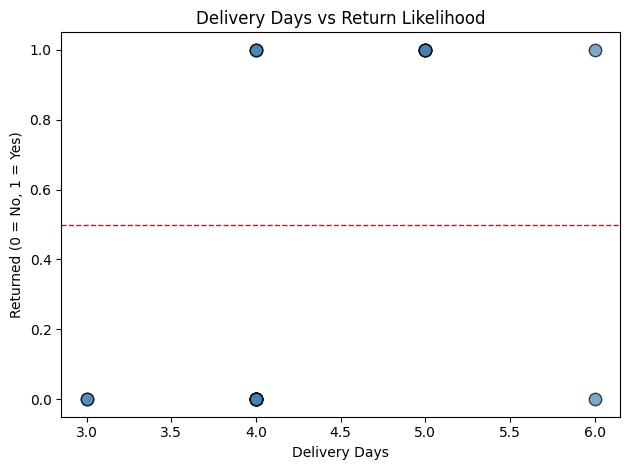

In [15]:
plt.scatter(data_frame_merged['Delivery_Days'], data_frame_merged['Returned'], color = 'steelblue', edgecolors = 'black', s = 80, alpha = 0.7)

plt.xlabel('Delivery Days')

plt.ylabel('Returned (0 = No, 1 = Yes)')

plt.title('Delivery Days vs Return Likelihood')

plt.axhline(y = 0.5, color = 'red', linestyle = '--', linewidth = 1)

plt.tight_layout()

plt.savefig('9_Insights_Delivery_Scatter.png')

plt.show()

#### `Step 10 :- Chart 2 — Partner Avg Delivery Days`

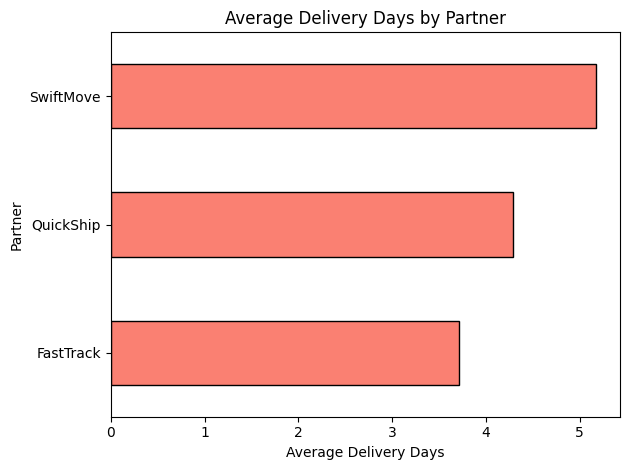

In [16]:
partner_performance['Average_Delivery_Days'].sort_values().plot(kind = 'barh', color = 'salmon', edgecolor = 'black')

plt.title('Average Delivery Days by Partner')

plt.xlabel('Average Delivery Days')

plt.ylabel('Partner')

plt.tight_layout()

plt.savefig('9_Insights_Partner_Delivery.png')

plt.show()

#### `Step 11 :- Print Outputs`

In [17]:
# Display all computed results clearly
print('\n--- FINAL OUTPUTS ---')

# Final merged dataset shape
print(f'\nMerged Shape: {data_frame_merged.shape}')

# Returned column counts
print(f'\nReturned Value Counts:\n{data_frame_merged["Returned"].value_counts()}')

# Delivery Days sample
print(f'\nDelivery Days (first 5 rows):\n{data_frame_merged[["Order_ID","Order_Date","Delivered_Date","Delivery_Days"]].head()}')

# Partner performance table
print(f'\nPartner Performance:\n{partner_performance}')

# Correlation scalar value
print(f'\nCorrelation (Delivery_Days vs Returned): {correlation_value.iloc[0,1]:.4f}')

# City-Warehouse average delivery days
print(f'\nCity-Warehouse Avg Delivery Days:\n{city_warehouse}')

# Return reasons
print(f'\nReturn Reasons:\n{data_frame_returns["Return_Reason"].value_counts()}')


--- FINAL OUTPUTS ---

Merged Shape: (20, 12)

Returned Value Counts:
Returned
0    11
1     9
Name: count, dtype: int64

Delivery Days (first 5 rows):
  Order_ID  Order_Date Delivered_Date  Delivery_Days
0     O001  2024-01-01     2024-01-04              3
1     O002  2024-01-03     2024-01-07              4
2     O003  2024-01-05     2024-01-09              4
3     O004  2024-01-07     2024-01-11              4
4     O005  2024-01-09     2024-01-13              4

Partner Performance:
              Average_Delivery_Days  Total_Orders  Total_Returns  \
Partner_Name                                                       
FastTrack                      3.71             7              0   
QuickShip                      4.29             7              4   
SwiftMove                      5.17             6              5   

              Return_Rate_Percentage  
Partner_Name                          
FastTrack                       0.00  
QuickShip                      57.14  
SwiftMove 

#### `Information`
> Orders = 20 rows

> Partners = 3 rows

> Returns = 9 rows

> Final merged dataset = 20 rows × 12 columns

> Returned column: 9 returned, 11 not returned 

#### `Data Insights`
> Merged dataset contains 20 rows and 12 columns.

> Highest avg delivery days partner = SwiftMove (5.17 days).

> Highest return rate partner = SwiftMove (83.33%).

> Correlation between delivery days and returns = 0.42 (moderate positive).

> City-Warehouse combo with highest avg delivery time = Bangalore-WH2 (5.33 days).

> Most common return reason = Late Delivery.

#### `Business Insights`
> SwiftMove is both slowest and highest return rate → critical crisis.

> Moderate positive correlation shows longer delivery → higher return likelihood.

> Bangalore-WH2 operations are slowest → urgent optimization needed.

> Late Delivery is top return reason → directly linked to delivery speed.

#### `Risks`
> Customer dissatisfaction due to late deliveries.

> High return rates (83%) → severe financial losses.

> Partner SwiftMove may damage brand reputation.

#### `Opportunities`
> Improve Bangalore-WH2 logistics efficiency.

> Terminate or renegotiate SwiftMove contract.

> Focus on FastTrack (lowest avg delivery days, lowest return rate).

> Use correlation evidence to justify investment in faster delivery systems.

#### `Recommendations`
> Immediate contract review for SwiftMove  
> - Evidence: Avg Delivery Days = 5.17, Return Rate = 83.33%.

> Optimize Bangalore-WH2 operations  
> - Evidence: Highest avg delivery time = 5.33 days.

> Invest more in FastTrack  
> - Evidence: Lowest avg delivery days and return rate.

> Address Late Delivery issue  
> - Evidence: Most frequent return reason.

#### `Expected Business Impact`
> Reduced delivery times → fewer returns.

> Improved partner performance → higher customer satisfaction.

> Lower operational costs → better profitability.

#### `Future Prediction`
> If SwiftMove issues persist, return rate may exceed 90%.

> Optimizing Bangalore-WH2 can reduce avg delivery time by 1–2 days.

> FastTrack expansion can set industry benchmark for speed.